# Tarea 15/4/26 - DFT/FFT

In [66]:
import numpy as np
import matplotlib.pyplot as plt

Retomamos las funciones de generador senoidal ruidoso de la TS1:

In [67]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

La DFT de una señal discreta $x[n]$ de longitud $N$ se define como:

$$X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

donde:
- $x[n]$ es la señal en el dominio del tiempo
- $X[k]$ es el espectro en el dominio de la frecuencia
- $N$ es el número de muestras
- $k$ es el índice de frecuencia
- $n$ es el índice de tiempo

#### Implementación de la DFT
Para implementar la DFT:

Representamos la señal $x[n]$ como un vector fila:

$$\mathbf{x} = \begin{bmatrix} x[0] & x[1] & \cdots & x[N-1] \end{bmatrix}$$

Construimos la **matriz de coeficientes** $E$ de tamaño NxN, cuyos elementos son:

$$E_{nk} = e^{-j \frac{2\pi}{N} n k}, \quad n, k = 0, 1, \dots, N-1$$

Es decir:

$$E = \begin{bmatrix}
1      & 1             & 1              & \cdots & 1 \\
1      & e^{-j\frac{2\pi}{N}} & e^{-j\frac{4\pi}{N}} & \cdots & e^{-j\frac{2\pi(N-1)}{N}} \\
1      & e^{-j\frac{4\pi}{N}} & e^{-j\frac{8\pi}{N}} & \cdots & e^{-j\frac{4\pi(N-1)}{N}} \\
\vdots & \vdots        & \vdots         & \ddots & \vdots \\
1      & e^{-j\frac{2\pi(N-1)}{N}} & e^{-j\frac{4\pi(N-1)}{N}} & \cdots & e^{-j\frac{2\pi(N-1)}{N}}
\end{bmatrix}$$

El espectro se obtiene mediante el producto matricial:

$$\mathbf{X} = \mathbf{x} \cdot E$$

Ya que al hacer el producto matricial, nos queda exactamente lo mismo que la DFT:

$$X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j \frac{2\pi}{N} n k}$$

In [68]:
def pds_dft(xx):
    N = len(xx)
    xn = np.array(xx).reshape((1, N))
    matriz_e = np.matrix([[np.exp(-1j * 2 * np.pi * n * k / N) for k in range(N)] for n in range(N)])
    xk = np.dot(xn, matriz_e)
    xk = np.asarray(xk).squeeze()
    return xk


N = 8
fs = 8
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = 0, SNR_db = "inf")
xk = pds_dft(xx)

Graficamos el espectro de la señal $x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8}\right), \quad n = 0, 1, \dots, 7$

No añadimos ruido (en la señal de entrada) todavía.

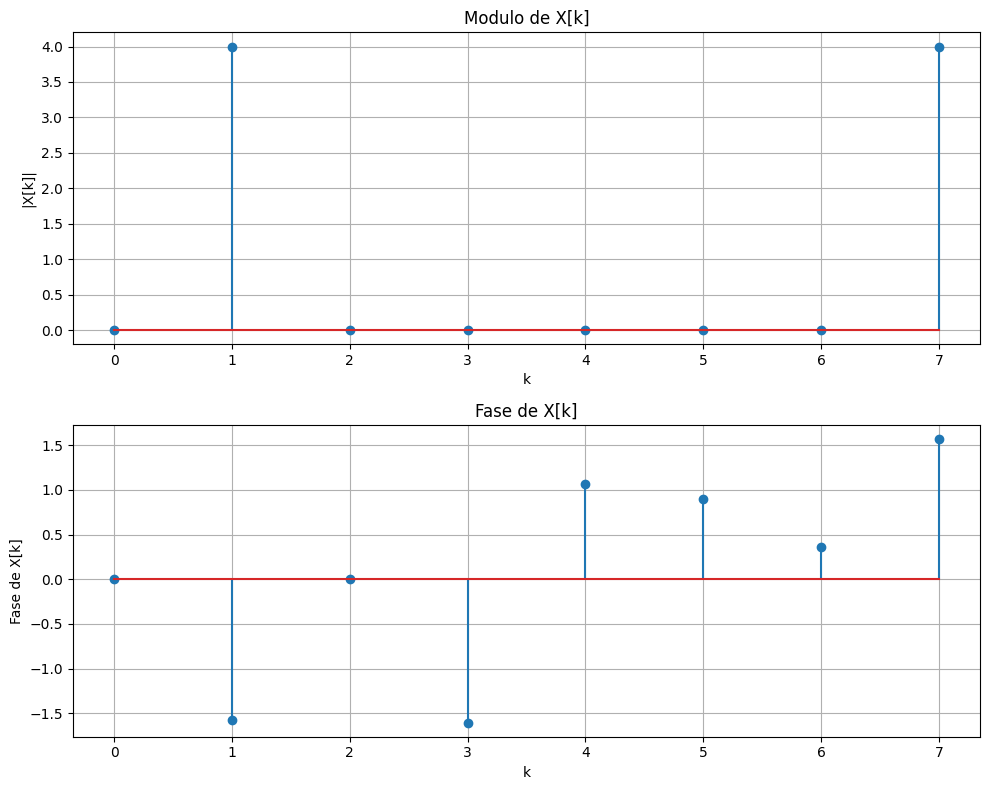

In [69]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)
axs[0].set_title("Modulo de X[k]")

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)
axs[1].set_title("Fase de X[k]")

plt.tight_layout()
plt.show()

Dada la señal discreta:

$$x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8}\right), \quad n = 0, 1, \dots, 7$$

La DFT produce dos impulsos en los bins $k = 1$ y $k = N-1 = 7$, correspondientes a $+f_0$ y $-f_0$:

$$X[k] = \frac{N}{2j} \left[ \delta[k - 1] - \delta[k - 7] \right]$$

Los demás coeficientes son cero (idealmente), ya que la frecuencia $f_0 = 1$ Hz cae exactamente en un bin de la DFT dado que $N = 8$ y $f_s = 8$ Hz.

En el módulo vemos que la teoría a simple vista se cumple a la perfección. Sin embargo en la fase vemos que no tenemos la fase impar que deberíamos obtener de una señal real.

Para analizar por qué sucede esto vamos a graficar la parte real e imaginaria del espectro en vez de módulo y fase:

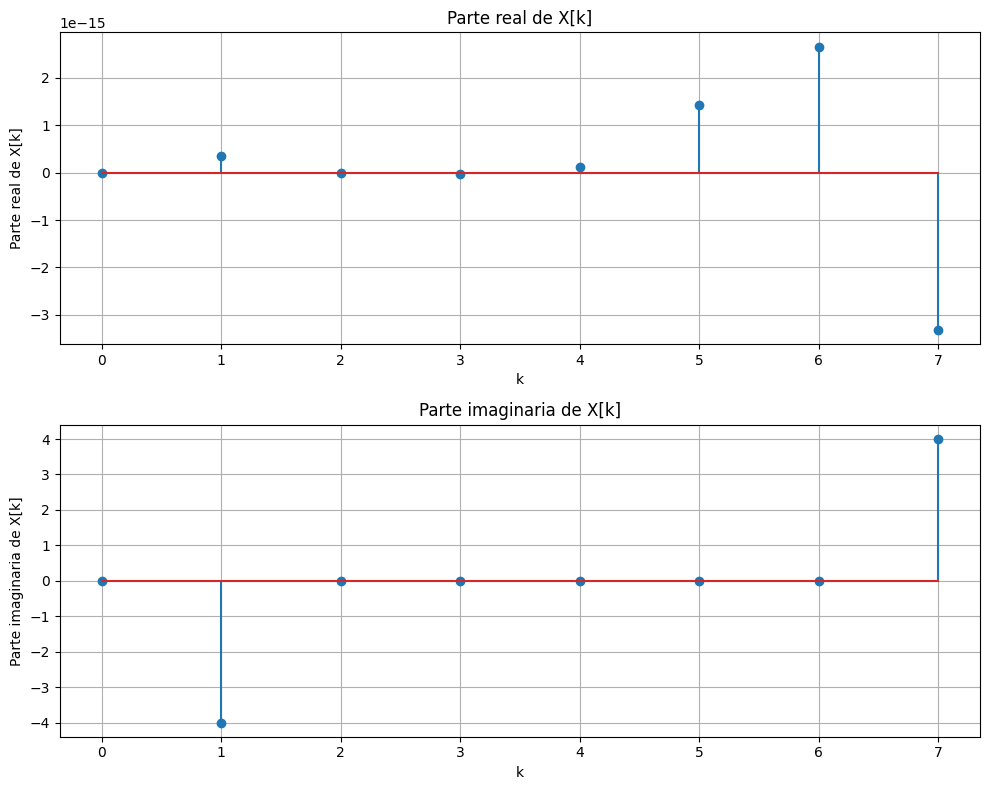

In [70]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)
axs[0].set_title("Parte real de X[k]")

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)
axs[1].set_title("Parte imaginaria de X[k]")

plt.tight_layout()
plt.show()

A simple vista vemos que la parte imaginaria da lo que debería dar, pero en la parte real vemos que aparecen valores cuando los números deberían ser completamente imaginarios para una senoidal pura.

Revisando el gráfico nuevamente, vemos que el gráfico de la parte real está escalado (1e-15). Vamos a imprimir las señales para ver realmente que hay en los vectores:

In [71]:
print("Parte real:")
print(np.real(xk))

print("Parte imaginaria:")
print(np.imag(xk))

Parte real:
[ 0.00000000e+00  3.53359980e-16  0.00000000e+00 -2.98172805e-17
  1.11022302e-16  1.43021011e-15  2.66453526e-15 -3.32057707e-15]
Parte imaginaria:
[ 0.00000000e+00 -4.00000000e+00  0.00000000e+00 -9.13872290e-16
  2.02906125e-16  1.78531325e-15  9.99200722e-16  4.00000000e+00]


Cuando imprimimos los vectores y vemos el fino de los números, nos damos cuenta que en realidad ni la parte real ni la imaginaria son completamente 0 cuando deberían serlo. Si imprimimos la fase de cada uno de estos números vamos a poder ver de dónde sale el ruido en la fase que veíamos al principio:

In [72]:
print(np.atan(np.imag(xk)/np.real(xk)))

[        nan -1.57079633         nan  1.53818049  1.07013544  0.89538649
  0.35877067 -1.57079633]


C:\Users\Tomas\AppData\Local\Temp\ipykernel_2536\887737782.py:1: RuntimeWarning: invalid value encountered in divide
  print(np.atan(np.imag(xk)/np.real(xk)))


Primero analizamos el warning: tenemos posiciones donde la parte real del número sí es realmente 0, entonces nos avisa que tenemos valores inválidos al dividir ya que no tenemos definido el comportamiento en la división por 0. Esto lo podemos ver en los valores nan (not a number) del vector de arriba.

Por otro lado, vemos que en la posición 1 y 7 del vector obtenemos la fase que corresponde a la senoidal, $-\pi/2$ y $+\pi/2$.

Concluyendo, el ruido en la fase que vimos arriba se debe al arcotangente entre estos decimales que aparecen por errores de punto flotante a la hora de resolver la dft.

#### Comparación entre FFT de numpy y DFT implementada

La **FFT** (Fast Fourier Transform) no es más que un algoritmo eficiente para calcular la DFT, reduciendo la complejidad computacional de $\mathcal{O}(N^2)$ a $\mathcal{O}(N \log N)$.

En teoría no deberíamos ver diferencias entre lo generado por cada una de estas.

Recordando la señal anterior:

$$x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8}\right), \quad n = 0, 1, \dots, 7$$

Vamos a calcular la fft de la misma y ver su módulo y su fase:

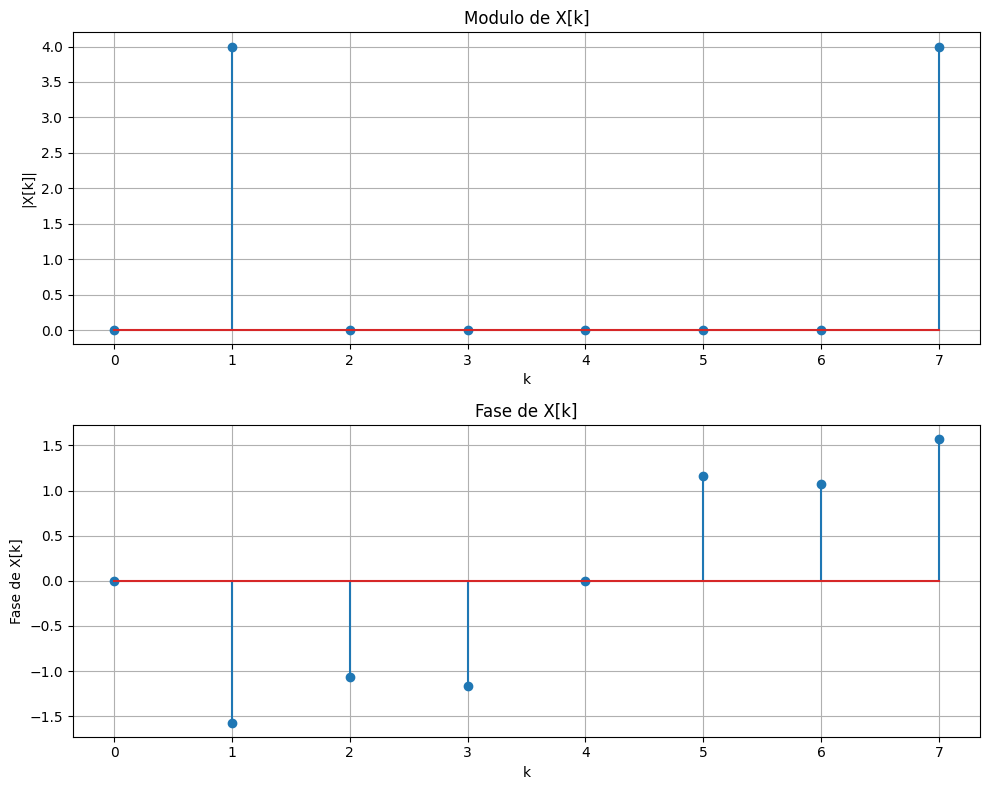

In [73]:
xk2 = np.fft.fft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk2))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)
axs[0].set_title("Modulo de X[k]")

axs[1].stem(np.arange(N), np.angle(xk2))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)
axs[1].set_title("Fase de X[k]")

plt.tight_layout()
plt.show()

De la misma manera que antes vemos que tenemos "ruido" en la fase. Vale la pena destacar que la parte erronea de la fase de la dft nuestra y la fft de numpy no es la misma. Seguramente se deba a que no estamos usando las mismas funciones (ni la misma cantidad de ellas) para hacer las cuentas entre números.


Ahora graficamos la parte real e imaginaria de la fft de la señal para asegurarnos que tenemos el mismo efecto que antes:

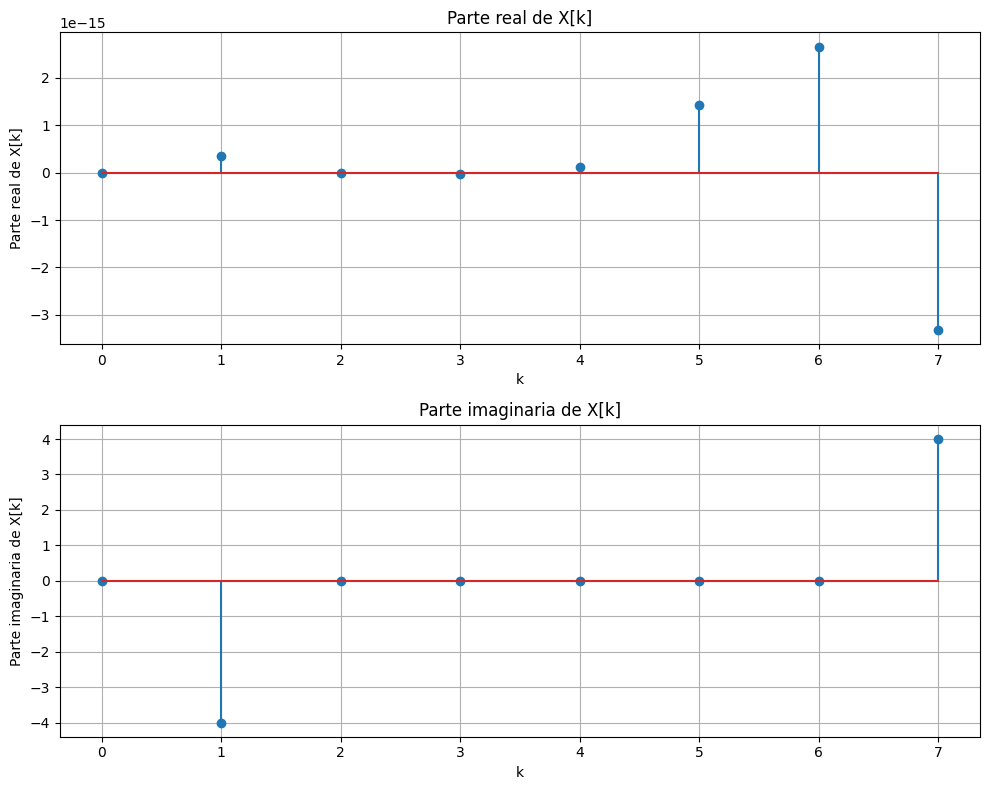

In [74]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)
axs[0].set_title('Parte real de X[k]')

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)
axs[1].set_title('Parte imaginaria de X[k]')

plt.tight_layout()
plt.show()

Efectivamente vemos que tenemos errores ínfimos en la parte real (y en la imaginaria aunque no se vea por la escala del gráfico), pero que aportan a una fase erronea.

#### FFT de otras señales para ver diferencias en los gráficos

Senoidal desplazada
1- Coseno

$$x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8} + \frac{\pi}{2}\right) = \cos\left(2\pi \cdot 1 \cdot \frac{n}{8}\right), \quad n = 0, 1, \dots, 7$$

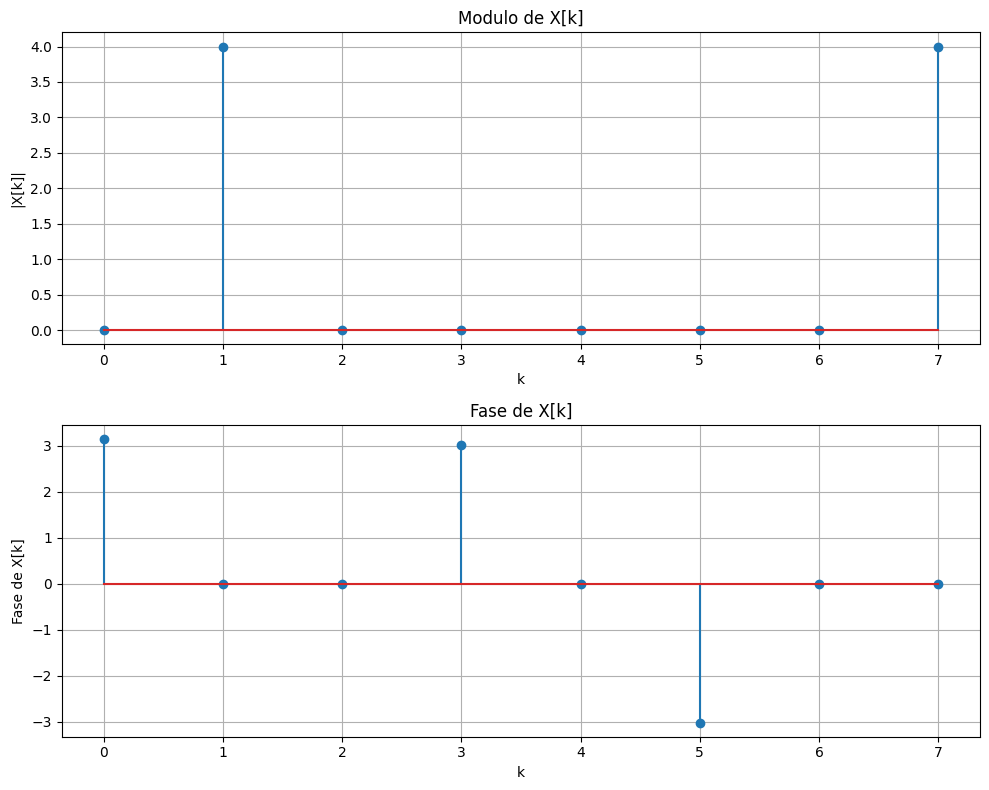

In [75]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = np.pi/2, SNR_db = "inf")

xk = np.fft.fft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)
axs[0].set_title("Modulo de X[k]")

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)
axs[1].set_title("Fase de X[k]")

plt.tight_layout()
plt.show()

Vemos ahora que, correspondiente con un coseno, la fase es 0 donde se concentra la potencia de la señal.

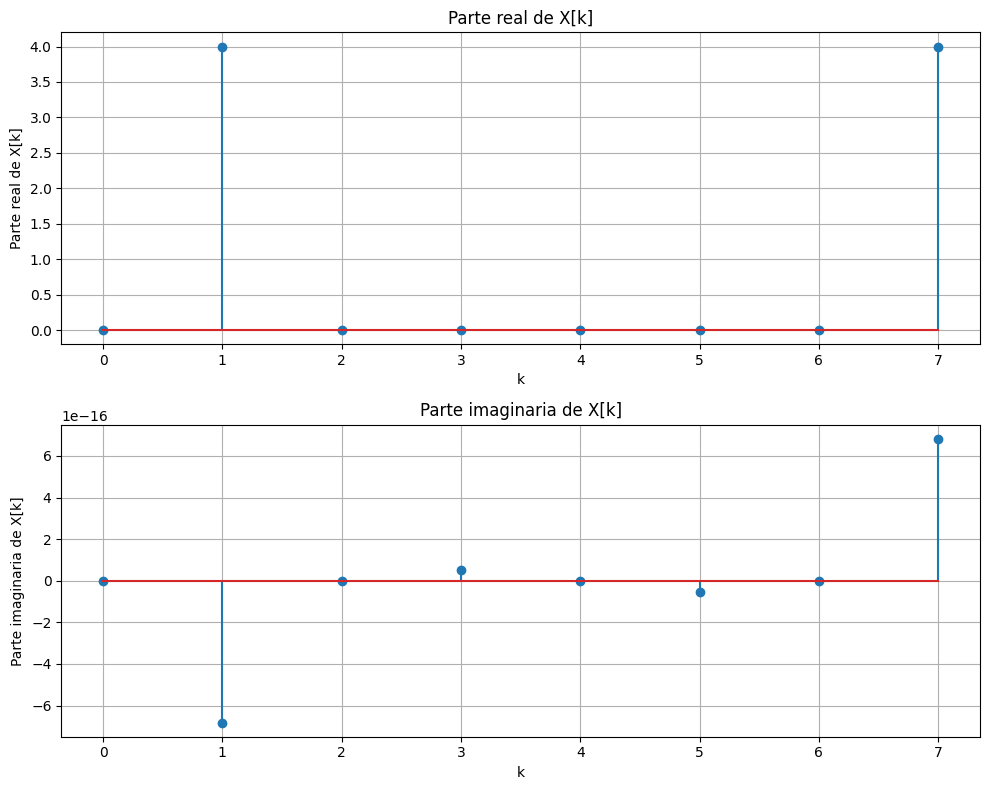

In [76]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)
axs[0].set_title('Parte real de X[k]')

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)
axs[1].set_title('Parte imaginaria de X[k]')

plt.tight_layout()
plt.show()

De la misma manera, vemos que tenemos 2 componentes completamente reales (fase 0), y tenemos ruido en la parte imaginaria de los números.

Senoidal desplazada por $\pi/3$

$$x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8} + \frac{\pi}{3}\right) = \cos\left(2\pi \cdot 1 \cdot \frac{n}{8}\right), \quad n = 0, 1, \dots, 7$$

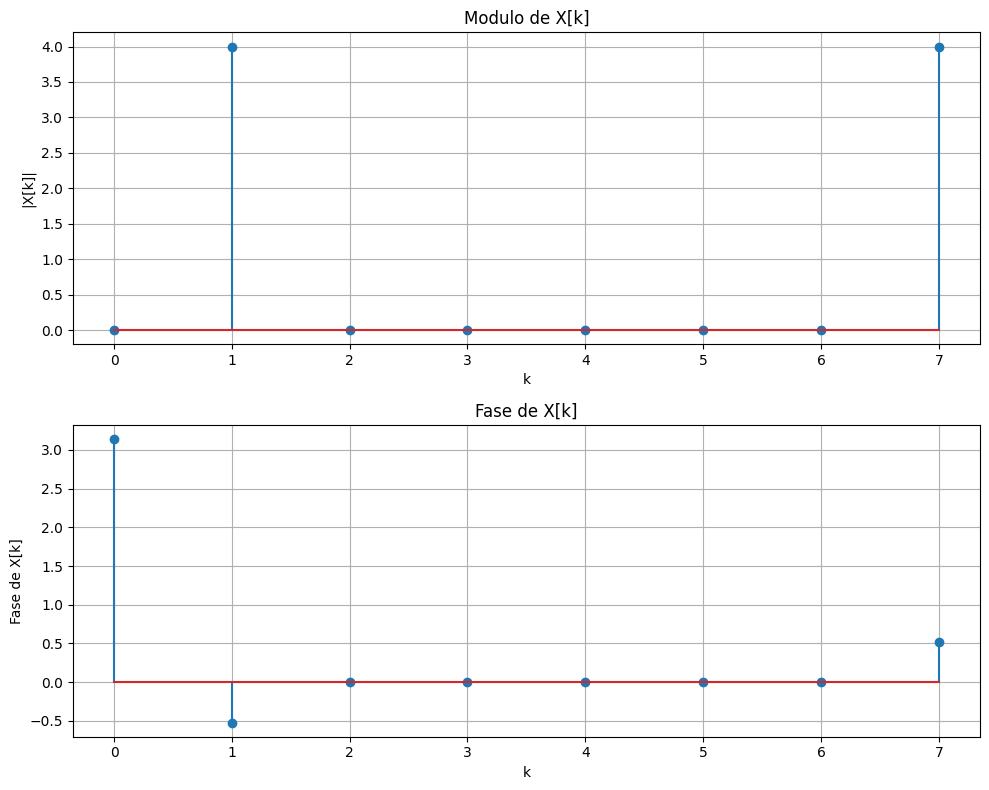

In [77]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = np.pi/3, SNR_db = "inf")

xk = np.fft.fft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)
axs[0].set_title("Modulo de X[k]")

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)
axs[1].set_title("Fase de X[k]")

plt.tight_layout()
plt.show()

Correspondiente a una señal senoidal desplazada, la potencia de la señal se sigue concentrando en los mismos bins. Cambia la fase en esos bins.

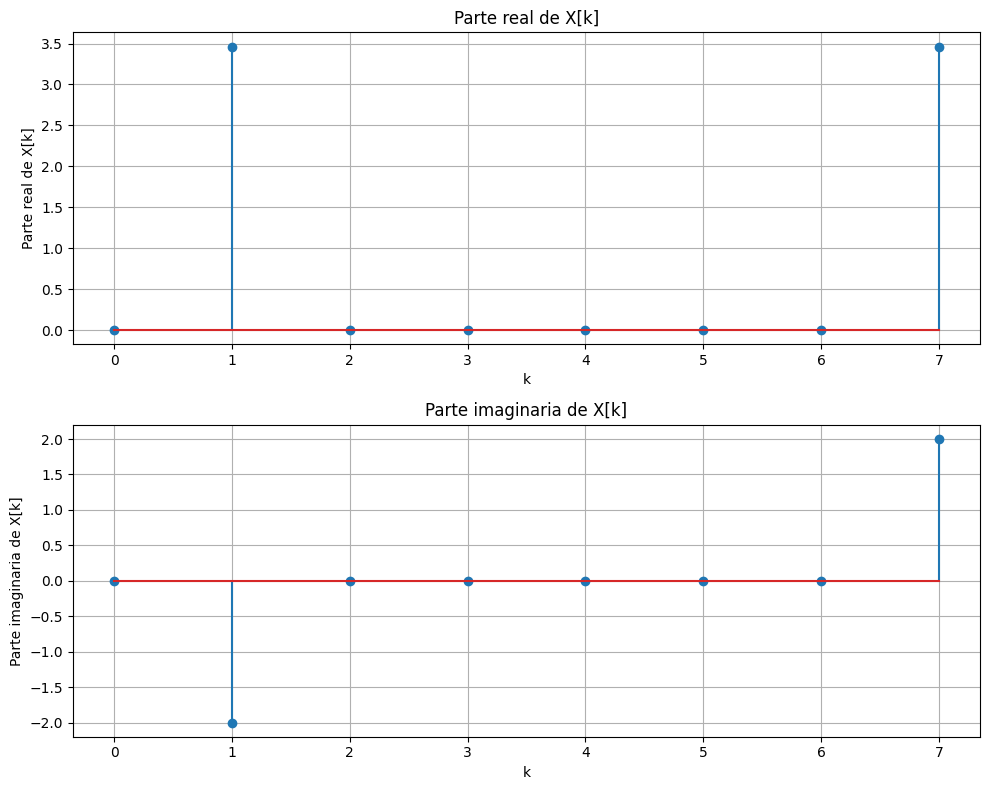

In [78]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)
axs[0].set_title('Parte real de X[k]')

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)
axs[1].set_title('Parte imaginaria de X[k]')

plt.tight_layout()
plt.show()

Vemos que ahora si obtenemos números distintos de 0 en parte real y también en imaginaria, podemos calcular entonces el arcotangente en esos puntos para obtener la fase en los bins donde se concentra la potencia:

In [79]:
print(np.angle(xk))

[ 3.14159265 -0.52359878  0.          0.          0.          0.
  0.          0.52359878]


En los bins 1 y 7 tenemos la fase esperada. A diferencia de antes casi tenemos una fase "perfecta", el único bin incorrecto es el bin 0.

Por último graficamos el modulo y fase de una senoidal con ruido AWGN:

$$x[n] = \sin\left(2\pi \cdot 1 \cdot \frac{n}{8}\right) + w[n], \quad w[n] \sim \mathcal{N}(0, \sigma^2), \quad \text{SNR} = 10 \text{ dB}$$

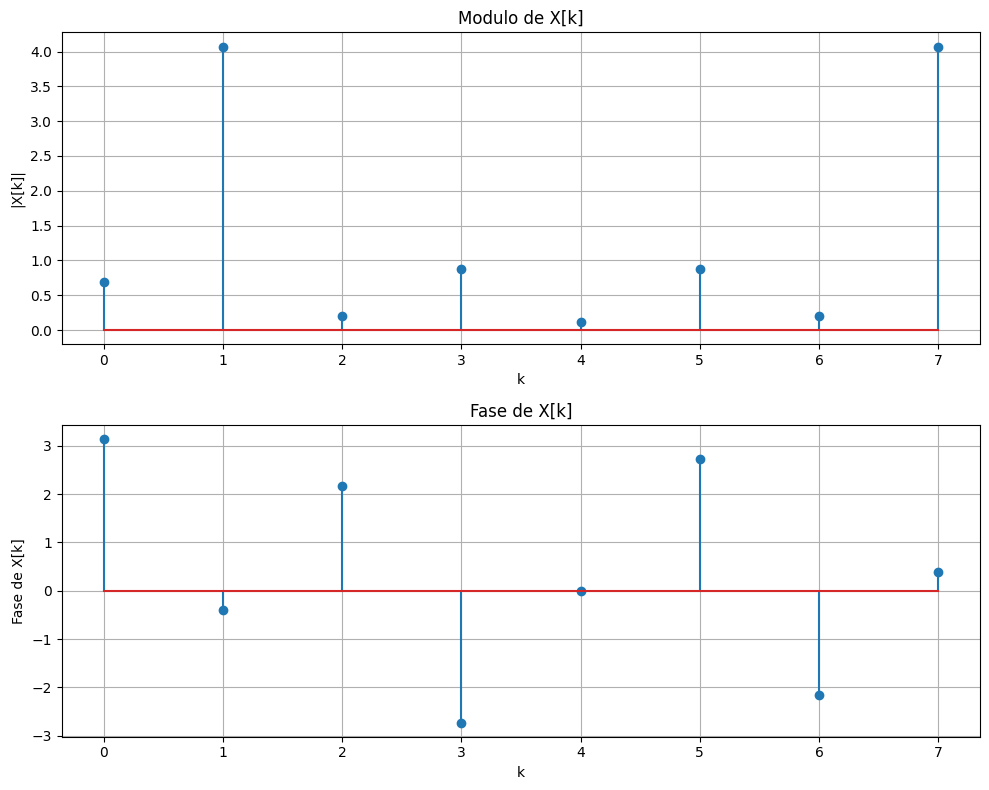

In [80]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = np.pi/3, SNR_db = 10)

xk = np.fft.fft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)
axs[0].set_title("Modulo de X[k]")

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)
axs[1].set_title("Fase de X[k]")

plt.tight_layout()
plt.show()

Claramente podemos ver que el piso del módulo subió y tenemos potencia (de ruido) en todos los bins, sumada a la potencia original de la senoidal en los bins 1 y 7.

#### Diferencias de tiempo entre DFT y FFT

Como se mencionó antes, hay diferencias de eficiencia entre la DFT y la FFT. Podemos medirlas:

In [81]:
import timeit

xx = np.random.rand(16)


t_dft = timeit.timeit(lambda: pds_dft(xx), number=200)
t_fft = timeit.timeit(lambda: np.fft.fft(xx), number=200)

print(f"Tiempo DFT: {t_dft:.6f} segundos")
print(f"Tiempo FFT: {t_fft:.6f} segundos")
print(f"Relación de tiempos (DFT/FFT): {t_dft / t_fft:.2f}")

Tiempo DFT: 0.024999 segundos
Tiempo FFT: 0.001031 segundos
Relación de tiempos (DFT/FFT): 24.24


Vemos que la dft es casi 25 veces mas lenta que la fft solo para 16 muestras.

Vale la pena aclarar que la manera que nosotros implementamos la dft tampoco es la ideal, ya que tenemos un bucle para rellenar la matriz de coeficientes E. Por eso este número da mayor que la mejora teórica que debería dar.